# Hybrid pipeline for Financial Fraud detection

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import lightgbm as lgb
from utils import set_seed
from preprocessing import preprocessing, preprocessing_lgbm
from features import rfm_features, signals_frauds
from models import AutoEncoderWrapper
from core.model_loader import ModelLoader
from core.pipeline import FraudDetectionPipeline
from core.metrics import MetricsCalculator

In [2]:
set_seed(42)

Path('model').mkdir(exist_ok=True)
Path('output').mkdir(exist_ok=True)

sns.set_style('whitegrid')
%matplotlib inline

FRAUD_COLOR_MAP = {
    'money laundering': '#E63946',
    'fraud by card': '#F4A261',
    'fraud by mule account': '#9B2226',
    'legitimate': '#2A9D8F'
}

## 1. Loading and data exploratory

In [3]:
df = pd.read_csv('data/demo_dataset.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Forcer les colonnes d'identifiant en object
for col in df.select_dtypes(include='int64'):
    df[col] = df[col].astype('object')

print(f'Shape: {df.shape}')
print(f'Period: {df["Timestamp"].min()} → {df["Timestamp"].max()}')
print(f'Banks: {df["From Bank"].nunique()} transmitters, {df["To Bank"].nunique()} receivers')
print(f'Formats: {df["Payment Format"].unique()}')
df.head()

Shape: (830886, 10)
Period: 2022-09-01 00:00:00 → 2022-09-16 12:10:00
Banks: 21724 transmitters, 8567 receivers
Formats: ['Credit Card' 'ACH' 'Bitcoin' 'Cheque' 'Wire' 'Cash' 'Reinvestment']


,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format
0,2022-09-06 18:14:00,70,10042B6F0,5923,80BB085D0,1686.290000,Yuan,1686.290000,Yuan,Credit Card
1,2022-09-10 17:33:00,692,803E5BCB0,110265,803E5BDF0,290025.770000,Yuan,290025.770000,Yuan,ACH
2,2022-09-05 22:38:00,12,80014CEB0,349,800214110,1949.030000,US Dollar,1949.030000,US Dollar,ACH
3,2022-09-04 00:09:00,217,80ED91011,272409,81AD21D41,0.187433,Bitcoin,0.187433,Bitcoin,Bitcoin
4,2022-09-01 06:27:00,1422,8003F4D80,22031,803081400,5241.120000,US Dollar,5241.120000,US Dollar,Cheque


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830886 entries, 0 to 830885
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Timestamp           830886 non-null  datetime64[ns]
 1   From Bank           830886 non-null  object        
 2   From Account        830886 non-null  object        
 3   To Bank             830886 non-null  object        
 4   To Account          830886 non-null  object        
 5   Amount Received     830886 non-null  float64       
 6   Receiving Currency  830886 non-null  object        
 7   Amount Paid         830886 non-null  float64       
 8   Payment Currency    830886 non-null  object        
 9   Payment Format      830886 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(7)
memory usage: 63.4+ MB


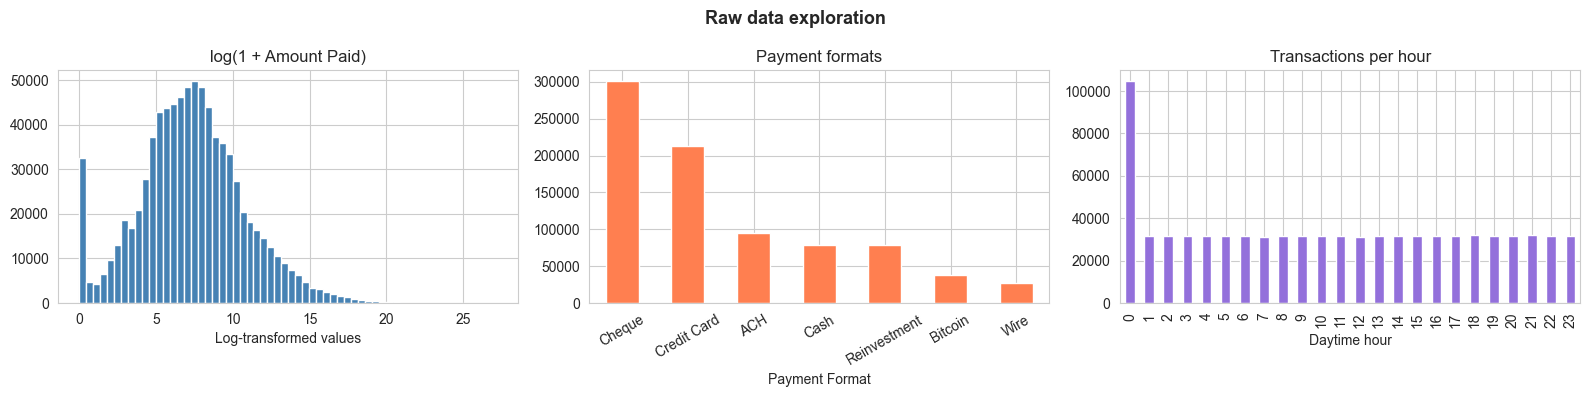

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(np.log1p(df['Amount Paid']), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('log(1 + Amount Paid)')
axes[0].set_xlabel('Log-transformed values')

df['Payment Format'].value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Payment formats')
axes[1].tick_params(axis='x', rotation=30)

df['Timestamp'].dt.hour.value_counts().sort_index().plot(kind='bar', ax=axes[2], color='mediumpurple', edgecolor='white')
axes[2].set_title('Transactions per hour')
axes[2].set_xlabel('Daytime hour')

plt.suptitle('Raw data exploration', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Feature engineering RFM

rfm_features() computes the indicators Recency, Frequency and Monetary
as well as behavioral signals (burst, smurfing, night, week-end…).

In [6]:
df_rfm = rfm_features(df)

new_cols = [c for c in df_rfm.columns if c not in df.columns]
print(f'{len(new_cols)} new features created :')
for col in new_cols:
    print(f'  - {col}')

19 new features created :
  - Hour
  - Day
  - DayOfWeek
  - Recency_Days
  - isNight
  - isWeekend
  - Freq_Tx
  - Unique_To_per_From
  - isBrust
  - Amount_Diff
  - Amount_Mean
  - Amount_Max
  - Small_Amount
  - Nb_Small_Tx
  - Log_Amount_Paid
  - Log_Amount_Diff
  - Log_Amount_Mean
  - Log_Amount_Max
  - Same_Bank_Transfer


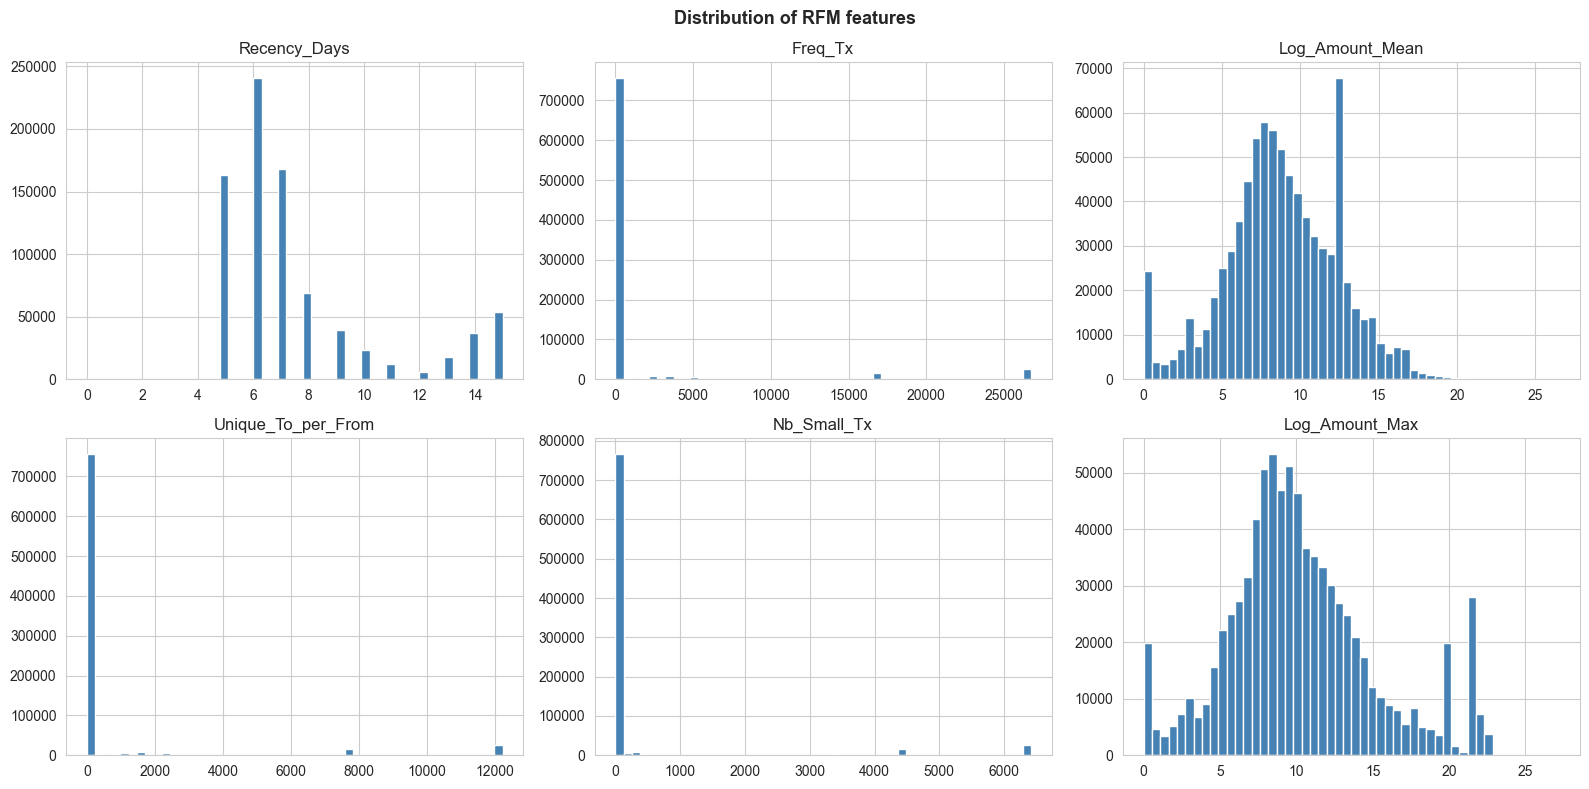

In [7]:
rfm_cols = ['Recency_Days', 'Freq_Tx', 'Log_Amount_Mean',
            'Unique_To_per_From', 'Nb_Small_Tx', 'Log_Amount_Max']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, rfm_cols):
    ax.hist(df_rfm[col].dropna(), bins=50, color='steelblue', edgecolor='white')
    ax.set_title(col)

plt.suptitle('Distribution of RFM features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Training of Autoencoder

Autoencoder learns to remodel normal transactions. A transaction difficult to remodel (high MSE error) is a candidate of anomaly.

In [8]:
# Preprocessing for Autoencoder (without the columns Pseudo_Labels)
X_ae_raw, num_cols, cat_cols = preprocessing(df)

ae_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
])

X_ae = ae_preprocessor.fit_transform(X_ae_raw)
print(f'Shape X_ae : {X_ae.shape}  ({X_ae.shape[1]} features in the network input)')

Shape X_ae : (830886, 10)  (10 features in the network input)


In [9]:
# Training
ae_model = AutoEncoderWrapper(epochs=20, batch_size=256, lr=1e-3, verbose=1, seed=42)
ae_model.fit(X_ae)

Epoch 1/20 - Loss: 0.275776
Epoch 2/20 - Loss: 0.000769
Epoch 3/20 - Loss: 0.000467
Epoch 4/20 - Loss: 0.000352
Epoch 5/20 - Loss: 0.000309
Epoch 6/20 - Loss: 0.000273
Epoch 7/20 - Loss: 0.000249
Epoch 8/20 - Loss: 0.000238
Epoch 9/20 - Loss: 0.000223
Epoch 10/20 - Loss: 0.000210
Epoch 11/20 - Loss: 0.000195
Epoch 12/20 - Loss: 0.000193
Epoch 13/20 - Loss: 0.000180
Epoch 14/20 - Loss: 0.000169
Epoch 15/20 - Loss: 0.000165
Epoch 16/20 - Loss: 0.000159
Epoch 17/20 - Loss: 0.000163
Epoch 18/20 - Loss: 0.000147
Epoch 19/20 - Loss: 0.000148
Epoch 20/20 - Loss: 0.000150


,epochs,20
,batch_size,256
,lr,0.001
,verbose,1
,device,'cpu'
,seed,42


In [10]:
# Anomalies detection
anomaly_scores = ae_model.score_samples(X_ae)
threshold_99 = np.percentile(anomaly_scores, 99)
anomaly_labels = (anomaly_scores > threshold_99).astype(int)
df['Anomaly_Score'] = anomaly_scores
df['isAnomaly'] = anomaly_labels
n_anom = anomaly_labels.sum()
print(f'Threshold percentile 99 : {threshold_99}')
print(f'Anomalies detected : {n_anom} / {len(df)}  ({n_anom/len(df)*100}%)')

Threshold percentile 99 : 0.001103072427213192
Anomalies detected : 8309 / 830886  (1.0000168494835633%)


In [11]:
# Sklearn pipeline : preprocessor + model (pour sauvegarde et réutilisation)
ae_pipeline = Pipeline([
    ('preprocessor', ae_preprocessor),
    ('ae', ae_model)
])

---
## 4. Clustering K-Means of anomalies

We segment the anomalies to identify different typology of fraud

In [12]:
df_anom = df[df['isAnomaly'] == 1].copy()
print(f'{len(df_anom)} anomalies à clusteriser')

X_km_raw, num_cols_km, cat_cols_km = preprocessing(df_anom)

km_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols_km),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols_km)
])

X_km = km_preprocessor.fit_transform(X_km_raw)
print(f'Shape X_km : {X_km.shape}')

8309 anomalies à clusteriser
Shape X_km : (8309, 12)


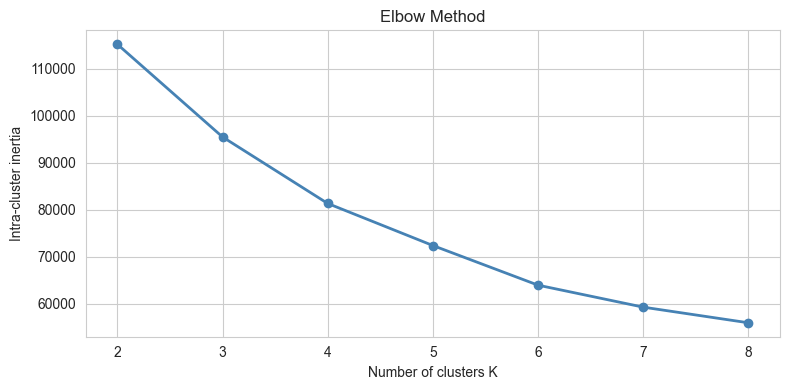

In [13]:
# Elbow method for choosing K
inertias = []
K_range  = range(2, 9)
for k in K_range:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_tmp.fit(X_km)
    inertias.append(km_tmp.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'o-', color='steelblue', linewidth=2)
plt.xlabel('Number of clusters K')
plt.ylabel('Intra-cluster inertia')
plt.title('Elbow Method')
plt.tight_layout()
plt.show()

In [14]:
# Final training with K = 4
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans.fit(X_km)

df_anom = df_anom.copy()
df_anom['Cluster'] = kmeans.labels_

# Update the main df
df['Cluster'] = np.nan
df.loc[df_anom.index, 'Cluster'] = df_anom['Cluster']

print('Distribution of clusters :')
print(df_anom['Cluster'].value_counts().sort_index())

kmeans_pipeline = Pipeline([
    ('preprocessor', km_preprocessor),
    ('kmeans', kmeans)
])

Distribution of clusters :
Cluster
0    3273
1     787
2     278
3    3971
Name: count, dtype: int64


## 5. Attribution of pseudo-labels

signals_frauds() calculates an alarm score per cluster and assigns the most compatible fraud type to each.

In [15]:
# calcultation of RFM features on clustered anomalies 
df_rfm_anom = rfm_features(df_anom)

# Automatic Pseudo-labels assignment 
df_labeled, cluster_to_fraud = signals_frauds(
    df_rfm_anom, cluster_col='Cluster', confidence_threshold=0.05
)

print('\n Mapping cluster → type of fraud :')
for cid, ftype in cluster_to_fraud.items():
    n = (df_anom['Cluster'] == cid).sum()
    print(f'Cluster {cid}  ({n} transactions) : {ftype}')

Cluster 2 assigned to : money laundering
Cluster 1 assigned to : fraud by card
Cluster 0 assigned to : fraud by mule account
Cluster 3 assigned to : legitimate

 Mapping cluster → type of fraud :
Cluster 2  (278 transactions) : money laundering
Cluster 1  (787 transactions) : fraud by card
Cluster 0  (3273 transactions) : fraud by mule account
Cluster 3  (3971 transactions) : legitimate


In [16]:
#Integrate pseudo-lables into the main dataframe 
df['Pseudo_Labels'] = 'legitimate'
df.loc[df_labeled.index, 'Pseudo_Labels'] = df_labeled['Pseudo_Labels']

print('Distribution of pseudo-labels :')
print(df['Pseudo_Labels'].value_counts())

Distribution of pseudo-labels :
Pseudo_Labels
legitimate               826548
fraud by mule account      3273
fraud by card               787
money laundering            278
Name: count, dtype: int64


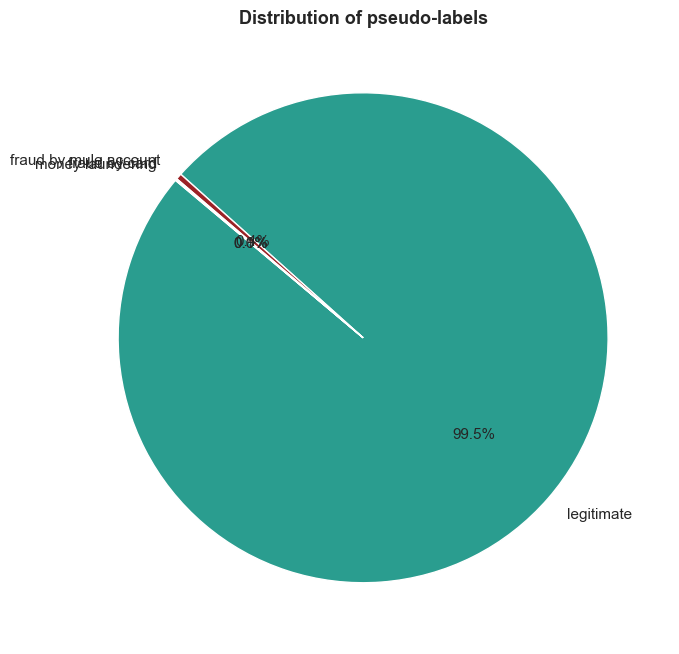

In [17]:
counts  = df['Pseudo_Labels'].value_counts()
colors  = [FRAUD_COLOR_MAP.get(l, '#AAAAAA') for l in counts.index]

plt.figure(figsize=(7, 7))
plt.pie(counts.values, labels=counts.index, colors=colors, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 11})
plt.title('Distribution of pseudo-labels', fontsize=13, fontweight='bold')
plt.tight_layout()

## 6. Training of the LightGBM classifier

LightGBM learns to generalize the pseudo-lables over all the population.

In [18]:
# preprocessing_lgbm wait for the columns 'Pseudo_Labels' from df
X_lgbm, y_lgbm, cat_cols_lgbm = preprocessing_lgbm(df)

print(f'Shape X : {X_lgbm.shape}')
print(f'Categorials : {cat_cols_lgbm}')
print(f'\n Distribution of the labels :')
print(y_lgbm.value_counts())

Shape X : (830886, 13)
Categorials : ['Receiving Currency', 'Payment Currency', 'Payment Format']

 Distribution of the labels :
Pseudo_Labels
legitimate               826548
fraud by mule account      3273
fraud by card               787
money laundering            278
Name: count, dtype: int64


In [19]:
# Encodage of the whole labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_lgbm)

print('Encoded classes :')
for i, cls in enumerate(label_encoder.classes_):
    print(f'{i} → {cls}')

Encoded classes :
0 → fraud by card
1 → fraud by mule account
2 → legitimate
3 → money laundering


In [20]:
# Stratified split 80 / 20
X_train, X_test, y_train, y_test = train_test_split(
    X_lgbm, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f'Train : {X_train.shape[0]} rows  |  Test : {X_test.shape[0]} rows')

Train : 664708 rows  |  Test : 166178 rows


In [21]:
# Training LightGBM
lgbm_pipeline = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

lgbm_pipeline.fit(X_train, y_train, categorical_feature=cat_cols_lgbm)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [22]:
# Evaluation on the test set 
y_pred  = lgbm_pipeline.predict(X_test)
y_proba = lgbm_pipeline.predict_proba(X_test)

print('Classification report (test)')
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Classification report (test)
                       precision    recall  f1-score   support

        fraud by card       1.00      1.00      1.00       157
fraud by mule account       1.00      1.00      1.00       655
           legitimate       1.00      1.00      1.00    165310
     money laundering       1.00      1.00      1.00        56

             accuracy                           1.00    166178
            macro avg       1.00      1.00      1.00    166178
         weighted avg       1.00      1.00      1.00    166178



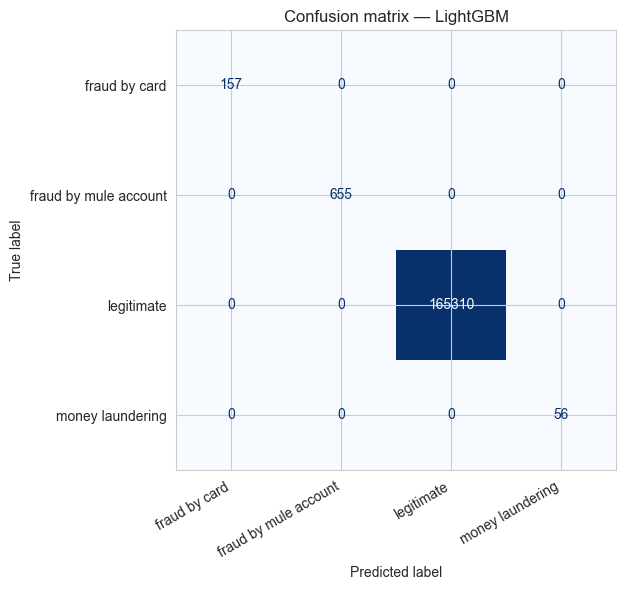

In [23]:
# Confuction matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=label_encoder.classes_
).plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion matrix — LightGBM')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [24]:
# AUC scores
auc_macro = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
auc_weighted = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
print(f'Macro AUC: {auc_macro}')
print(f'Weighted AUC: {auc_weighted}')

Macro AUC: 1.0
Weighted AUC: 1.0


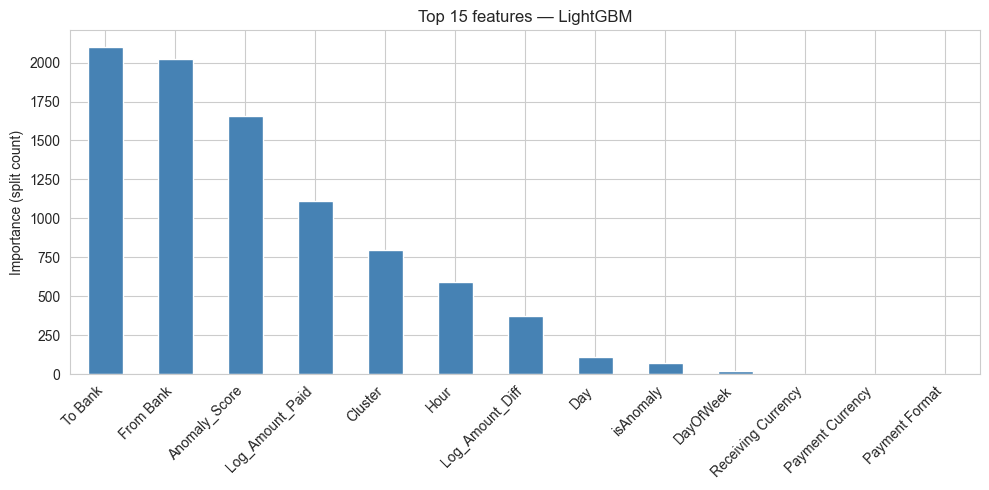

In [25]:
# Importance of features
feat_imp = pd.Series(
    lgbm_pipeline.feature_importances_,
    index=X_lgbm.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 15 features — LightGBM')
plt.ylabel('Importance (split count)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Saving the models 

We are exporting the four artifacts required by ModelLoader :
- ae_pipeline.pkl : preprocessor + Autoencoder
- kmeans_pipeline.pkl : preprocessor + K-Means
- lgbm_pipeline.pkl : LightGBM
- label_encoder.pkl : text label encoder 

In [26]:
joblib.dump(ae_pipeline,     'model/ae_pipeline.pkl')
joblib.dump(kmeans_pipeline, 'model/kmeans_pipeline.pkl')
joblib.dump(lgbm_pipeline,   'model/lgbm_pipeline.pkl')
joblib.dump(label_encoder,   'model/label_encoder.pkl')

['model/label_encoder.pkl']

## 8. Reloading and use on new data 

We reload the models from the disk via ModelLoader and FraudDetectionPipeline, exactly as the API does in production.

In [27]:
loader = ModelLoader(model_dir='model')
loader.load_all()

pipeline = FraudDetectionPipeline(loader)
metrics_c = MetricsCalculator(loader.label_encoder)

print(f'Classes detected : {pipeline.get_class_names().tolist()}')

Classes detected : ['fraud by card', 'fraud by mule account', 'legitimate', 'money laundering']


In [28]:
# New data : simulation using an unused subset
df_new = pd.read_csv('data/demo_dataset.csv').sample(2000, random_state=99)

df_result = pipeline.run_full_pipeline(df_new)

cols_pred = ['Anomaly_Score', 'isAnomaly', 'Cluster', 'Pseudo_Labels', 'Prediction']
print(f'Pipeline executed on {len(df_result)} transactions')
df_result[cols_pred].head(10)

c:\Users\Hervé\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\Hervé\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Cluster 2.0 assigned to : money laundering
Cluster 1.0 assigned to : fraud by mule account
Pipeline executed on 2000 transactions


,Anomaly_Score,isAnomaly,Cluster,Pseudo_Labels,Prediction
466945,0.000462,0.0,NaN,legitimate,legitimate
188462,0.000514,0.0,NaN,legitimate,legitimate
53677,0.000658,0.0,NaN,legitimate,legitimate
65133,0.000355,0.0,NaN,legitimate,legitimate
104050,0.000413,0.0,NaN,legitimate,legitimate
560488,0.000616,0.0,NaN,legitimate,legitimate
597963,0.000353,0.0,NaN,legitimate,legitimate
557335,0.000340,0.0,NaN,legitimate,legitimate
724287,0.000772,0.0,NaN,legitimate,legitimate
78141,0.000170,0.0,NaN,legitimate,legitimate


## 9. Final evaluation and visualizations

In [29]:
n_total  = len(df_result)
n_anom   = (df_result['isAnomaly'] == 1).sum()
n_frauds = (df_result['Prediction'] != 'légitime').sum()

print('=' * 40)
print('RESULT ON NEW DATA')
print('=' * 40)
print(f'Total transactions: {n_total}')
print(f'Anomalies detected: {n_anom}  ({n_anom/n_total*100}%)')
print(f'Predicted frauds: {n_frauds}  ({n_frauds/n_total*100}%)')
print()
print('Distribution of predictions:')
print(df_result['Prediction'].value_counts())

RESULT ON NEW DATA
Total transactions: 2000
Anomalies detected: 20  (1.0%)
Predicted frauds: 2000  (100.0%)

Distribution of predictions:
Prediction
legitimate          1894
fraud by card        104
money laundering       2
Name: count, dtype: int64


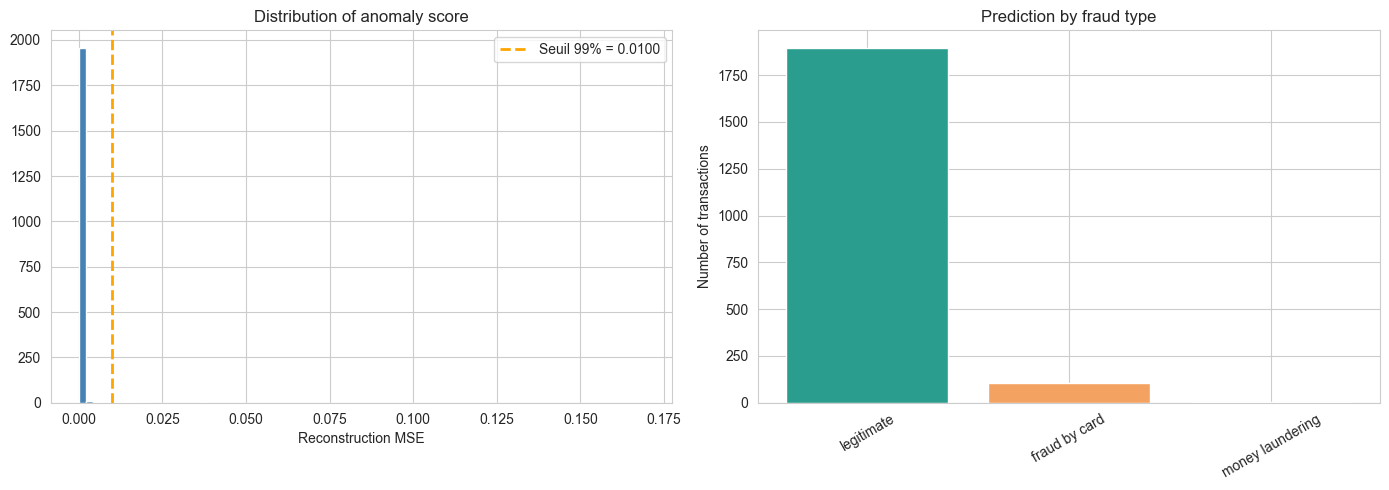

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Anomaly score
axes[0].hist(df_result['Anomaly_Score'], bins=80, color='steelblue', edgecolor='white')
seuil = np.percentile(df_result['Anomaly_Score'], 99)
axes[0].axvline(seuil, color='orange', linestyle='--', linewidth=2, label=f'Seuil 99% = {seuil:.4f}')
axes[0].set_title("Distribution of anomaly score")
axes[0].set_xlabel('Reconstruction MSE')
axes[0].legend()

# Predictions
counts = df_result['Prediction'].value_counts()
colors = [FRAUD_COLOR_MAP.get(l, '#AAAAAA') for l in counts.index]
axes[1].bar(counts.index, counts.values, color=colors, edgecolor='white')
axes[1].set_title('Prediction by fraud type')
axes[1].set_ylabel('Number of transactions')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

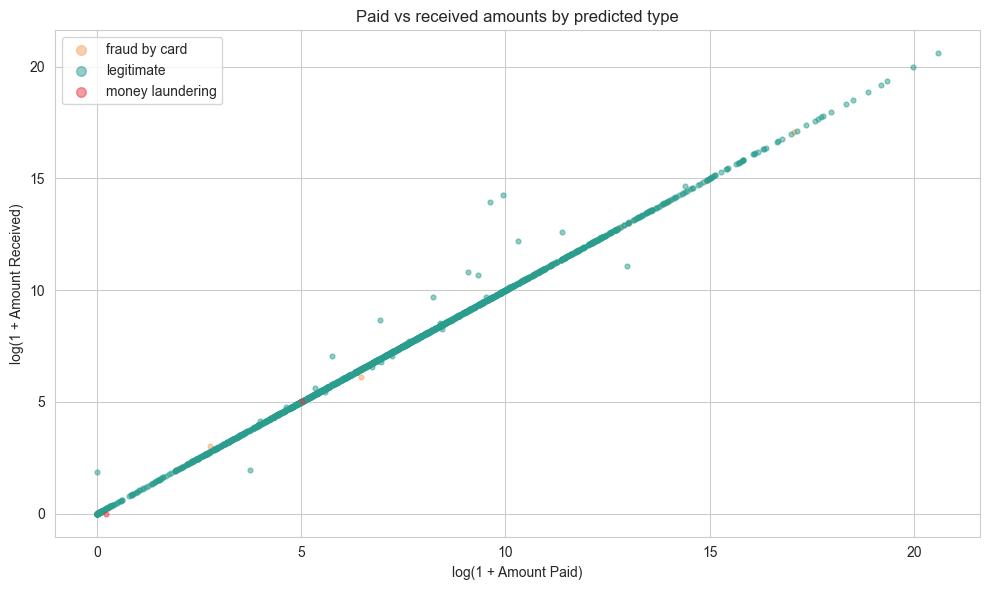

In [31]:
# Scatter paid vs received amounts, colored by prediction
plt.figure(figsize=(10, 6))
for label, grp in df_result.groupby('Prediction'):
    x = np.log1p(pd.to_numeric(grp['Amount Paid'], errors='coerce'))
    y = np.log1p(pd.to_numeric(grp['Amount Received'], errors='coerce'))
    plt.scatter(x, y, c=FRAUD_COLOR_MAP.get(label, '#AAAAAA'), label=label, alpha=0.5, s=12)

plt.xlabel('log(1 + Amount Paid)')
plt.ylabel('log(1 + Amount Received)')
plt.title('Paid vs received amounts by predicted type')
plt.legend(markerscale=2)
plt.tight_layout()
plt.show()

In [32]:
# Formal metrics on new data
try:
    y_true_enc = loader.label_encoder.transform(df_result['Pseudo_Labels'])
    y_pred_enc = loader.label_encoder.transform(df_result['Prediction'])
    y_proba_new = pipeline.predict_proba(df_result)

    auc = metrics_c.compute_auc_scores(y_true_enc, y_proba_new)
    print(f'AUC macro : {auc["auc_macro"]}')
    print(f'AUC weighted : {auc["auc_weighted"]}')

    clf = metrics_c.compute_classification_metrics(y_true_enc, y_pred_enc)
    print('\n Classification report')
    print(clf['report'])
except Exception as e:
    print(f'Metrics not available : {e}')

Metrics not available : pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: Prediction: object


In [33]:
# Exporting the results
df_result.to_csv('output/predictions.csv', index=False)
df_result[df_result['Prediction'] != 'legitimate'].to_csv('output/fraudes_detectees.csv', index=False)

print('output/predictions.csv')
print(f'output/fraudes_detectees.csv ({(df_result["Prediction"] != "legitimate").sum()} rows)')

output/predictions.csv
output/fraudes_detectees.csv (106 rows)
